# Model Training - BoardGames Dataset

In [17]:
import pandas as pd
import numpy as np
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from scipy.stats import randint

In [2]:
df = pd.read_csv("../data/processed/boardgames_features.csv")

In [3]:
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'log_users_rated', 'log_owned', 'log_wishing', 'playtime_mean', 'game_cluster', 'pca_cat_0', 'pca_cat_1', 'pca_cat_2', 'pca_cat_3', 'pca_cat_4', 'pca_cat_5', 'pca_cat_6', 'pca_cat_7', 'pca_cat_8', 'pca_cat_9', 'pca_cat_10', 'pca_cat_11', 'pca_cat_12', 'pca_cat_13', 'pca_cat_14', 'pca_cat_15', 'pca_cat_16', 'pca_cat_17', 'pca_cat_18', 'pca_cat_19', 'pca_cat_20', 'pca_cat_21', 'pca_cat_22', 'pca_cat_23', 'pca_cat_24', 'pca_cat_25', 'pca_cat_26', 'pca_cat_27', 'pca_cat_28', 'pca_cat_29', 'pca_cat_30', 'pca_cat_31', 'pca_cat_32', 'pca_cat_33', 'pca_cat_34', 'pca_cat_35', 'pca_cat_36', 'pca_cat_37', 'pca_cat_38', 'pca_cat_39', 'pca_cat_40', 'pca_cat_41', 'pca_cat_42', 'pca_cat_43', 'pca_cat_44', 'pca_cat_45', 'pca_cat_46', 'pca_cat_47', 'pca_cat_48', 'pca_cat_49', 'pca_cat_50', 'pca_cat_51', 'pca_mech_0', 'pca_mech_1', 'pca_mech_2', 'pca_mech_3', 'pca_mech_4', 'pc

## Train/test split

Our target is to determine how good any game is, based on it's rating

In [3]:
X = df.drop(columns=["average_rating","id","name", "rank"])         #id and name are not used
y = df["average_rating"]

To prevent data leakage, we removed the rank variable (as it's determined by sorting the average_rating)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Training models

We are going to use 1 baseline model and 5 advanced models

In [5]:
#Models definition, where we can adjust parameters
lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gb = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    random_state=42,
    verbose=False
)

et = ExtraTreesRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

In [5]:
#function to compare models. Show results in a dataframe

def compare_models(models, X_train, X_test, y_train, y_test):

    results = []

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        cv = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

        results.append({
            "Model": name,
            "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R2": r2,
            "CV Mean": cv.mean()
        })

    return pd.DataFrame(results)

In [8]:
#Make models dict and call the function
models = {
    "Linear Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "CatBoost": cat,
    "ExtraTrees": et
}

compare_models(models, X_train, X_test, y_train, y_test)

,Model,MSE,RMSE,R2,CV Mean
0,Linear Regression,0.314351,0.560670,0.582462,0.565583
1,Random Forest,0.266358,0.516099,0.646209,0.636545
2,Gradient Boosting,0.261639,0.511506,0.652478,0.639392
3,XGBoost,0.239694,0.489586,0.681626,0.664995
4,CatBoost,0.259093,0.509011,0.655860,0.644440
5,ExtraTrees,0.270232,0.519839,0.641064,0.627907


We use R2 and RMSE and not Accuracy or F1, because our predictions are based on numbers

R2: X% -> the model explain the x% of the variance of the rating

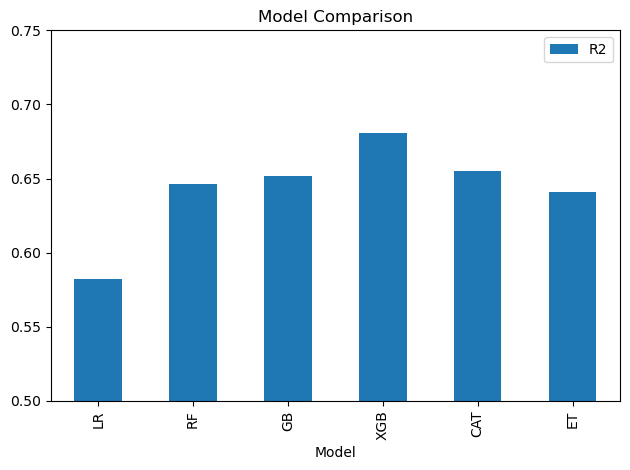

In [9]:
model_scores = pd.DataFrame({
    "Model": ["LR","RF","GB","XGB","CAT","ET"],
    "R2":[0.582,0.646,0.652,0.681,0.655,0.641]
})

model_scores.set_index("Model").plot(kind="bar")

plt.ylim(0.5, 0.75)
plt.title("Model Comparison")
plt.tight_layout()
plt.show()

<h4 style="color: #24e712;"> The XGBoost Model is the one with better results </h4>

## Hyperparameters

GridSearchCV

In [24]:
#We use GridSearchCV to check for the best parameters for our XGB
param_grid = {
    "n_estimators": [300, 400, 500, 600],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb = XGBRegressor(
    n_jobs=1, 
    eval_metric='logloss',
    tree_method='hist'
)

grid = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=2,           # Limita los procesos paralelos externos
    pre_dispatch='2*n_jobs', # Evita saturar la memoria con copias de datos
    verbose=1
)

if __name__ == '__main__': # Obligatorio en Windows para evitar errores de multiprocesamiento
    grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best score:", grid.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}
Best score: 0.6660261748765601


In [27]:
best_grid = grid.best_estimator_

best_grid_y_pred = best_grid.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, best_grid_y_pred)
r2 = r2_score(y_test, best_grid_y_pred)

print(f"R2: {(r2):.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")

R2: 0.6763292045467401
RMSE: 0.4936414151007369


## Stacking

#### We are going to try:

- Model 1 → PCA (categories)
- Model 2 → PCA (mechanics)
- Model 3 → numeric variables
- ↓
- Stacking

In [11]:
print("Column headers:", list(df))

Column headers: ['id', 'name', 'average_rating', 'yearpublished', 'minplayers', 'maxplayers', 'minage', 'averageweight', 'rank', 'log_users_rated', 'log_owned', 'log_wishing', 'playtime_mean', 'game_cluster', 'pca_cat_0', 'pca_cat_1', 'pca_cat_2', 'pca_cat_3', 'pca_cat_4', 'pca_cat_5', 'pca_cat_6', 'pca_cat_7', 'pca_cat_8', 'pca_cat_9', 'pca_cat_10', 'pca_cat_11', 'pca_cat_12', 'pca_cat_13', 'pca_cat_14', 'pca_cat_15', 'pca_cat_16', 'pca_cat_17', 'pca_cat_18', 'pca_cat_19', 'pca_cat_20', 'pca_cat_21', 'pca_cat_22', 'pca_cat_23', 'pca_cat_24', 'pca_cat_25', 'pca_cat_26', 'pca_cat_27', 'pca_cat_28', 'pca_cat_29', 'pca_cat_30', 'pca_cat_31', 'pca_cat_32', 'pca_cat_33', 'pca_cat_34', 'pca_cat_35', 'pca_cat_36', 'pca_cat_37', 'pca_cat_38', 'pca_cat_39', 'pca_cat_40', 'pca_cat_41', 'pca_cat_42', 'pca_cat_43', 'pca_cat_44', 'pca_cat_45', 'pca_cat_46', 'pca_cat_47', 'pca_cat_48', 'pca_cat_49', 'pca_cat_50', 'pca_cat_51', 'pca_mech_0', 'pca_mech_1', 'pca_mech_2', 'pca_mech_3', 'pca_mech_4', 'pc

In [11]:
cat_cols = [c for c in df.columns if "cat" in c]
mech_cols = [c for c in df.columns if "mech" in c]

numeric_cols = [
    "yearpublished",
    "minplayers",
    "maxplayers",
    "playtime_mean",
    "minage",
    "averageweight",
    "log_users_rated",
    "log_owned",
    "log_wishing"
]

We will use the best previous model with its better parameters

In [12]:
xgb_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'   # Vital for big data
}

In [ ]:

model_cat = Pipeline([
    ('selector', ColumnTransformer([('sel', 'passthrough', cat_cols)])),
    ('xgb', XGBRegressor(**xgb_params))
])

model_mech = Pipeline([
    ('selector', ColumnTransformer([('sel', 'passthrough', mech_cols)])),
    ('xgb', XGBRegressor(**xgb_params))
])

model_num = Pipeline([
    ('selector', ColumnTransformer([('sel', 'passthrough', numeric_cols)])),
    ('xgb', XGBRegressor(**xgb_params))
])

# Stacking integration with Cross Validation
meta_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,         # Low depth because we only have 3 variables
    learning_rate=0.05,
    tree_method='hist'
)

stacking_regressor = StackingRegressor(
    estimators=[
        ('cat_expert', model_cat),
        ('mech_expert', model_mech),
        ('num_expert', model_num)
    ],
    final_estimator=meta_xgb, 
    cv=5,      # Cross validation
    n_jobs=-1,
    passthrough=True  # Checks the 3 predictions + all original features
)
# Only one training
stacking_regressor.fit(X_train, y_train)


,estimators,"[('cat_expert', ...), ('mech_expert', ...), ...]"
,final_estimator,"XGBRegressor(...ree=None, ...)"
,cv,5
,n_jobs,-1
,passthrough,True
,verbose,0
,transformers,"[('sel', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


In [16]:
preds = stacking_regressor.predict(X_test)

print("--- Individual Results ---")
for name, pipeline in stacking_regressor.named_estimators_.items():
    score = pipeline.score(X_test, y_test)
    print(f"R2 Individual {name}: {score:.4f}")

print("\n--- Global Results ---")    
print(f"R2 Stacking: {r2_score(y_test, preds):.4f}")

--- Individual Results ---
R2 Individual cat_expert: 0.2095
R2 Individual mech_expert: 0.3354
R2 Individual num_expert: 0.6384

--- Global Results ---
R2 Stacking: 0.6609


# Best Model

After using Hyperparameters and Stacking, the best model is the XGBoost with the first parameters

In [18]:
best_model= XGBRegressor(**xgb_params)

In [19]:
best_model.fit(X_train, y_train)
best_model_y_pred = best_model.predict(X_test)
# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, best_model_y_pred))
r2 = r2_score(y_test, best_model_y_pred)

print(f"Best model RMSE: {(rmse):.4f}")
print(f"Best model R2: {(r2):.4f}")

Best model RMSE: 0.4896
Best model R2: 0.6816


## Visualizations

Predicted vs Real ratings

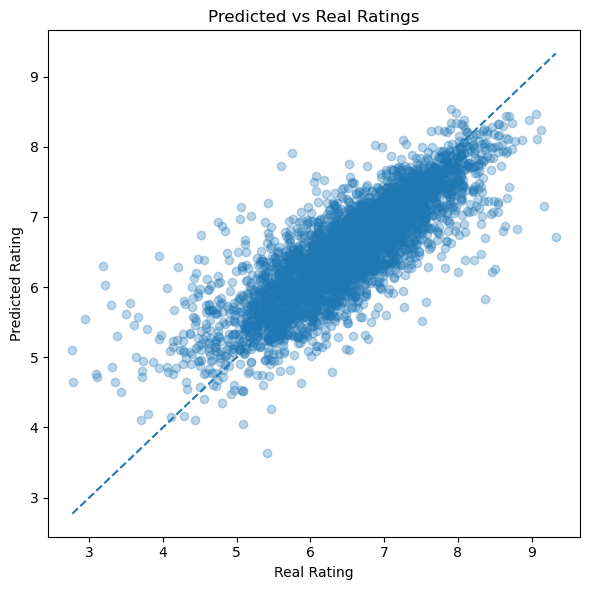

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, best_model_y_pred, alpha=0.3)

plt.xlabel("Real Rating")
plt.ylabel("Predicted Rating")

plt.title("Predicted vs Real Ratings")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.tight_layout()
plt.show()

Errors distribution

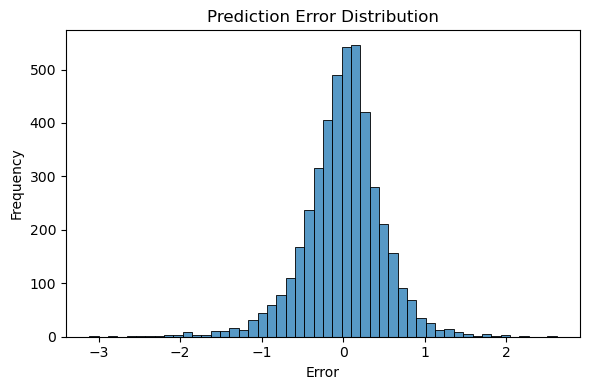

In [ ]:
errors = y_test - best_model_y_pred

plt.figure(figsize=(6,4))
sns.histplot(errors, bins=50)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#### Feature Importance

What factors are most influential in making a game enjoyable?

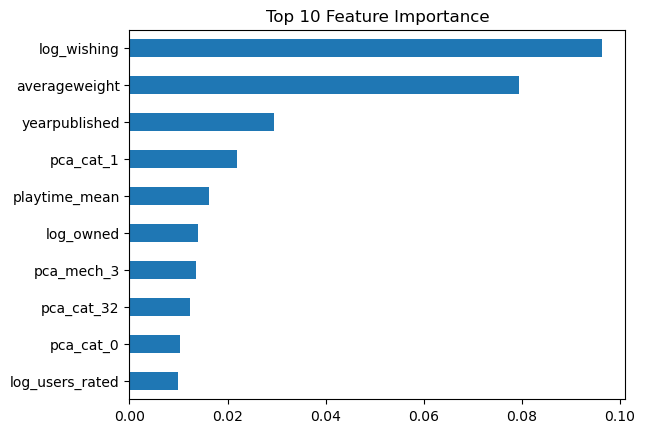

In [ ]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False).head(10)

importance.plot(kind="barh")

plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout
plt.show()

### Best model found

It is XGBoost with the following parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}

In [ ]:
import joblib

joblib.dump(best_model, "boardgame_rating_predictor.pkl")
print("Best model found saved as 'boardgame_rating_predictor.pkl'")

Best model found saved as 'boardgame_rating_predictor.pkl'
